# Project 4: Binary Classification

## Problem Statement

**Project overview**

A real-world challenge frequently faced by analysts in the banking sector will be addressed. Banks accumulate vast amounts of client data, which can be utilized to maintain client engagement and offer personalized banking products or proposals.

Direct marketing, involving communication through channels such as in-person interactions (e.g., bank visits), phone calls, emails, or messaging apps, is a common strategy employed by banks and insurance companies. However, this approach is resource-intensive and costly.

The aim is to enable banks to target clients most likely to accept specific offers, thereby optimizing outreach efforts. Data from a recent marketing campaign conducted by a real bank, focused on encouraging clients to open deposits, will be analyzed. Patterns will be identified, and key factors influencing clients’ decisions to invest in this bank will be determined. This analysis will enhance bank revenue and clarify the target audience for future advertising and promotional campaigns.

This case study, based on real banking data, will serve as a valuable addition to a data science portfolio.

**Business Task**

Characteristics that identify clients most likely to open a deposit in the bank will be determined to improve the effectiveness of marketing campaigns.

**Technical Task**

As a Data Science specialist, a machine learning model will be developed to predict whether a client will open a deposit based on their characteristics, addressing a binary classification task.

**Main Objectives:**

1. **`Comprehensive Data Exploration`**: Data will be thoroughly investigated beyond merely calculating metrics and generating visualizations to uncover meaningful insights.  

2. **`Identification of Target Audience Traits`**: Distinctive characteristics of potential clients will be revealed to define the target audience (TA) clearly and increase bank profitability.

3. **`Innovative Approach`**: A variety of tools and techniques will be employed creatively to enhance prediction quality.

In [42]:
# load the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8')

from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn.ensemble import StackingClassifier
from sklearn import metrics

from sklearn.model_selection import train_test_split 
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

import optuna

In [43]:
import warnings
warnings.filterwarnings('ignore')

In [44]:
#from comet_ml import Experiment

#@title CometML set up
#project_name = 'project Classification'
#workspace = ''
#api_key = ''

In [45]:
# Start the experiment

#experiment = Experiment(project_name=project_name, workspace=workspace, api_key = api_key, log_code=True)

## 1. Data Familiarization, Handling Missing Values, and Outliers

In [46]:
# Load the data

df = pd.read_csv('data/bank_fin.csv', sep = ';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,"2 343,00 $",yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,"45,00 $",no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,"1 270,00 $",yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,"2 476,00 $",yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,"184,00 $",no,no,unknown,5,may,673,2,-1,0,unknown,yes


The dataset description will be added:

### Bank Client Data:

- **`age`**: Client's age.

- **`job`**: Client's occupational sector.

- **`marital`**: Client's marital status.

- **`education`**: Client's education level.

- **`default`**: Whether the client has an overdue loan.

- **`housing`**: Whether the client has a housing loan.

- **`loan`**: Whether the client has a personal loan.

- **`balance`**: Client's account balance.

### Data Related to the Last Contact in the Context of the Current Marketing Campaign:

- **`contact`**: Type of contact with the client.

- **`month`**: Month of the last contact.

- **`day`**: Day of the last contact.

- **`duration`**: Duration of the contact in seconds.

### Other Features:

- **`campaign`**: Number of contacts with this client during the current campaign.

- **`pdays`**: Number of days elapsed since the last marketing campaign before the contact in the current campaign.

- **`previous`**: Number of contacts before the current campaign.

- **`poutcome`**: Outcome of the previous marketing campaign.

### Target Variable:

- **`deposit`**: Indicates whether the client will agree to open a deposit in the bank. This is the variable to be predicted in this case.

In [47]:
# Investigate the data for missing values

df.isna().sum().sort_values(ascending=False).head(10)

balance     25
age          0
day          0
poutcome     0
previous     0
pdays        0
campaign     0
duration     0
month        0
contact      0
dtype: int64

In [48]:
# Investigate features for implicit missing values

df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

The value "unknown" indicates missing data

In [49]:
# Transform the balance feature to be correctly interpreted as a floating-point number

df['balance'] = df['balance'].replace({r'\$': '', ',': '.', ' ':''}, regex=True).astype(float)
df['balance'].head(5)

0    2343.0
1      45.0
2    1270.0
3    2476.0
4     184.0
Name: balance, dtype: float64

In [50]:
# Handle missing values in the balance feature by replacing them with the median value for this feature

df['balance'] = df['balance'].fillna(df['balance'].median())

In [51]:
# Check the data types of the features, calculate the mean of the balance feature

mean_balance = df['balance'].mean().round(3)
print(f'Mean balance: {mean_balance}')

Mean balance: 1526.936


In [52]:
# Investigate the education feature for implicit missing values

df['education'].value_counts()

education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

Similar to the job feature, the value "unknown" in this feature indicates missing data

In [53]:
# Handle missing values in the categorical features job and education by replacing them with the mode values

df['job'] = df['job'].replace('unknown', df['job'].mode()[0], regex=True)
df['education'] = df['education'].replace('unknown', df['education'].mode()[0], regex=True)

In [54]:
# record the most frequent job and education values for later use

most_freq_job = df['job'].mode()[0]
most_freq_edu = df['education'].mode()[0]

df_copy = df[(df['job'] == most_freq_job) & (df['education'] == most_freq_edu)]

print(f'Most frequent job is {most_freq_job}')
print(f'Most frequent education is {most_freq_edu}')

Most frequent job is management
Most frequent education is secondary


The feature representing client balance will be investigated for outliers.

In mathematical statistics, several approaches exist to identify outliers. Outliers will be considered as values lying outside the range defined by the lower bound, calculated as the first quartile minus 1.5 times the interquartile range `(Q1 - 1.5 * IQR)`, and the upper bound, calculated as the third quartile plus 1.5 times the interquartile range `(Q3 + 1.5 * IQR)`. These boundaries will be determined, and the data will be filtered to remove outliers.

In [55]:
# Introduce a function to identify outliers for the balance feature using the Tukey method

def outliers_iqr(data, feature):
    """ Function to identify outliers

    Args:
        data (DataFrame): Input DataFrame
        feature (DataFrame[column]): Specified feature column

    Returns:
        DataFrame: Returns two DataFrames—one with cleaned data and another with outliers
    """
    x = data[feature]
    quantile_1, quantile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr = quantile_3 - quantile_1
    lower_bound = quantile_1 - (1.5 * iqr)
    upper_bound = quantile_3 + (1.5 * iqr)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned   

# Apply the function to identify outliers for the balance feature

outliers, cleaned_df = outliers_iqr(df, 'balance')

# Output the number of outliers and the size of the cleaned dataset

print(f"Number of outliers found using the Tukey method: {outliers.shape[0]}")
print(f'Size of the cleaned dataset after removing outliers: {cleaned_df.shape[0]}')

Number of outliers found using the Tukey method: 1057
Size of the cleaned dataset after removing outliers: 10105


In [56]:
# Check the boundaries defined for identifying outliers

q3 = np.percentile(df['balance'], 75)
q1 = np.percentile(df['balance'], 25)
lower_bound = q1 - (1.5 * (q3 - q1))
upper_bound = q3 + (1.5 * (q3 - q1))

print('Lower bound: ', lower_bound)
print('Upper bound: ', upper_bound)

Lower bound:  -2241.0
Upper bound:  4063.0


## 2. Exploratory Data Analysis (EDA)

The data will be explored to detect initial patterns and formulate hypotheses regarding factors influencing client decisions.

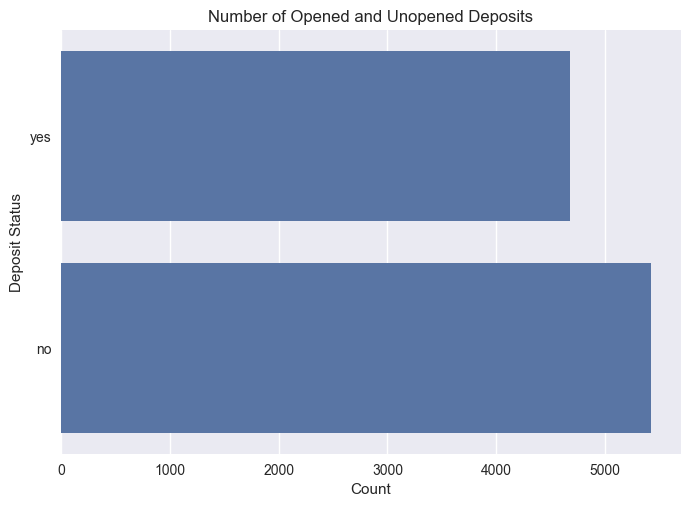

In [57]:
# Examine the class distribution in the data for imbalance and visualize the results

sns.countplot(cleaned_df['deposit'])
plt.title("Number of Opened and Unopened Deposits")
plt.xlabel("Count")
plt.ylabel("Deposit Status")

#experiment.log_figure('target_feature_distribution', plt)
plt.show();


In [58]:
# Analyze class distribution for imbalance

cleaned_df['deposit'].value_counts()

deposit
no     5424
yes    4681
Name: count, dtype: int64

**From the graph and target feature counts, the data appears balanced**

In [59]:
# Descriptive statistics for numerical variables

cleaned_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10105.0,40.895497,11.734931,18.0,32.0,38.0,48.0,95.0
balance,10105.0,807.653538,994.151966,-2049.0,95.0,445.0,1227.0,4063.0
day,10105.0,15.590302,8.441510,1.0,8.0,15.0,22.0,31.0
duration,10105.0,368.742603,346.651524,2.0,137.0,252.0,490.0,3881.0
campaign,10105.0,2.517170,2.707159,1.0,1.0,2.0,3.0,43.0
pdays,10105.0,51.319644,109.644179,-1.0,-1.0,-1.0,2.0,854.0
previous,10105.0,0.816230,2.243795,0.0,0.0,0.0,1.0,58.0


From the descriptive statistics, the following is observed:

- Client ages range from 18 to 95 years, with no minors.

- The balance includes both negative and positive values.

- There is a large variation in call duration, from 2 to nearly 4000 seconds.

In [60]:
# Descriptive statistics for categorical variables

cleaned_df.describe(include='object').T

,count,unique,top,freq
job,10105,11,management,2315
marital,10105,3,married,5715
education,10105,3,secondary,5517
default,10105,2,no,9939
housing,10105,2,no,5243
loan,10105,2,no,8712
contact,10105,3,cellular,7283
month,10105,12,may,2617
poutcome,10105,4,unknown,7570
deposit,10105,2,no,5424


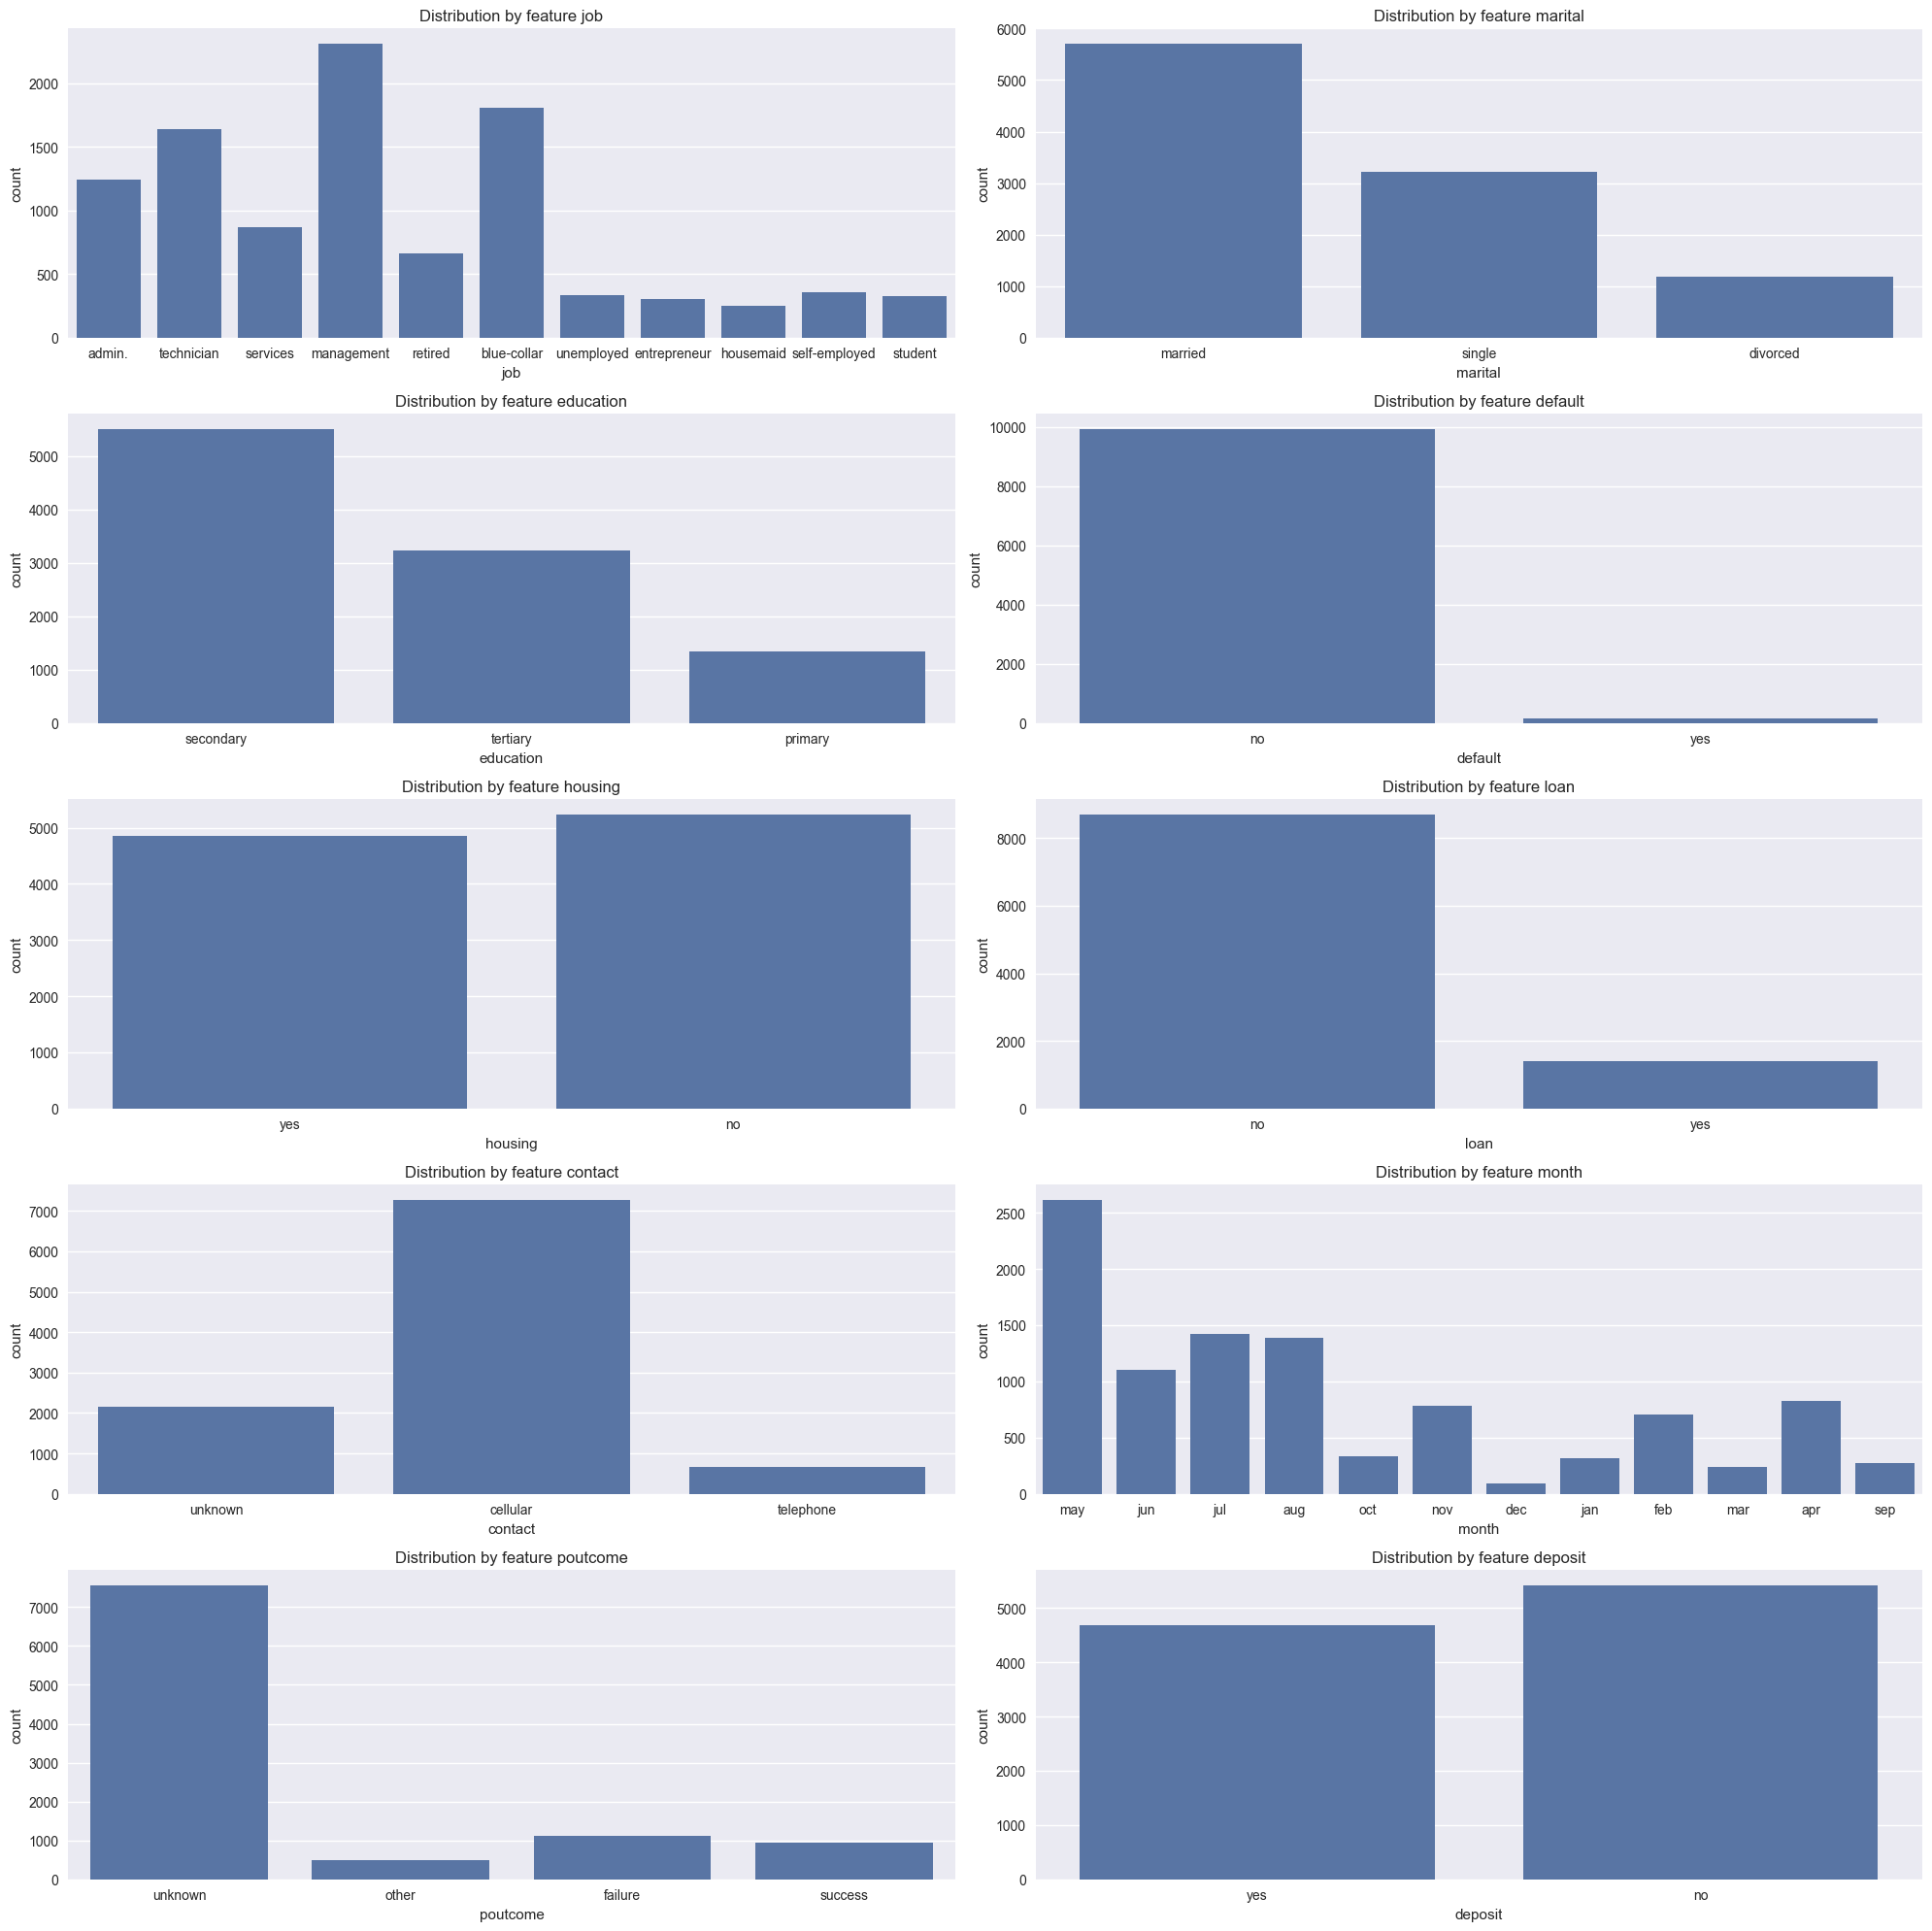

In [61]:
# Plot visualizations for categorical features to illustrate the results

categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

# Create a figure and subplots

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(20, 20))

# Iterate through all features and plot graphs

for i, feature in enumerate(categorical_features):
    
    # Obtain subplot coordinates
    ax = axes[i // 2, i % 2]
    sns.countplot(data=cleaned_df, x=feature, ax=ax)
    ax.set_title(f"Distribution by feature {feature}")

# Adjust spacing and display
plt.tight_layout()

#experiment.log_figure('Category_feature_distribution', plt)
plt.show();

From the descriptive statistics and visualizations of categorical features, the following is observed:

- Clients are employed in 11 occupational sectors, most commonly in management.

- Most clients do not have overdue loans.

- The campaign was conducted across all 12 months.

- Most client contacts occurred in May, with the fewest in December.

- Approximately 50% of clients are married.

- Data on previous campaign outcomes is unavailable for most clients.

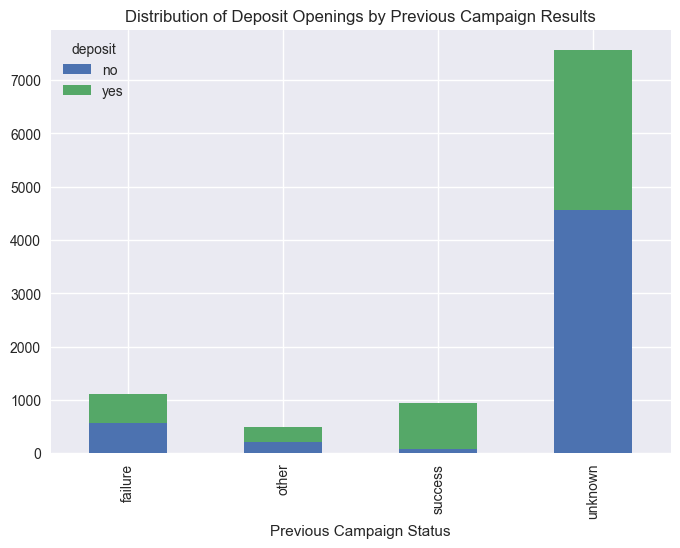

In [62]:
# Determine which status of the previous marketing campaign shows a higher success rate in the current campaign compared to failures

types = cleaned_df.groupby("poutcome")['deposit'].value_counts(normalize=False).unstack()
types.plot(kind='bar', stacked='True')
plt.xlabel('Previous Campaign Status')
plt.title('Distribution of Deposit Openings by Previous Campaign Results')
plt.show();

**Clients who opened a deposit in the previous campaign are more likely to open one again**

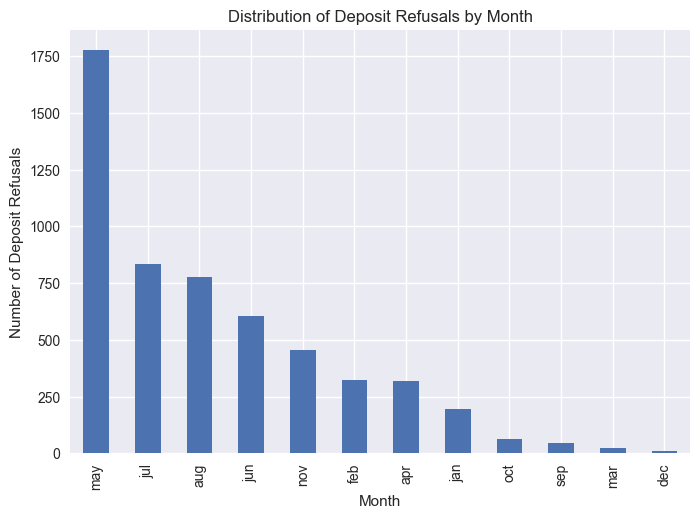

In [63]:
# Identify the month with the highest refusal rate for opening a deposit

monthes = cleaned_df[cleaned_df['deposit'] == 'no'].groupby('month', as_index=False)['deposit'].size().sort_values(by='size', ascending=False)
monthes.plot(kind='bar', x='month', y='size', legend=False)
plt.xlabel('Month')
plt.ylabel('Number of Deposit Refusals')
plt.title('Distribution of Deposit Refusals by Month')
plt.show();

**The highest number of refusals occurred in May, and the lowest in December, correlating with the overall number of campaign contacts**

In [64]:
# Create age groups and determine which groups are more likely to open a deposit than refuse

def age_range(x):
    """ Function to determine age categories

    Args:
        x (int): Age value in the DataFrame

    Returns:
        object: Age category
    """
    if x < 30:
        x = 'young'
    elif 30 <= x < 40:
        x = 'low mid age'
    elif 40 <= x < 50:
        x = 'mid age'
    elif 50 <= x < 60:
        x = 'high mid age'  
    elif 60 <= x:
        x = 'senior'
    return x

# Apply the function to the cleaned DataFrame

cleaned_df['age_category'] = cleaned_df['age'].apply(age_range)

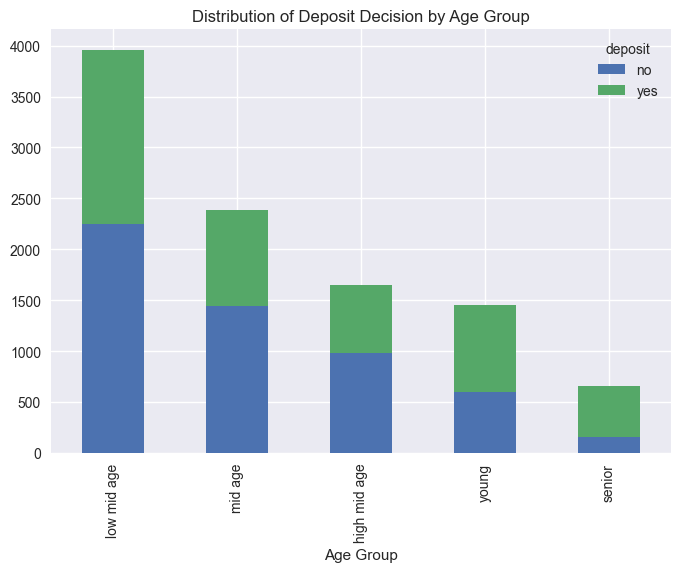

In [65]:
# Visualize which age groups are more likely to open a deposit than refuse

age_data = cleaned_df.groupby('age_category')['deposit'].value_counts(normalize=False).unstack()
age_data = age_data.loc[age_data.sum(axis=1).sort_values(ascending=False).index]
age_data.plot(kind='bar', stacked='True');

plt.xlabel('Age Group')
plt.title('Distribution of Deposit Decision by Age Group')
plt.show();


**Young and elderly individuals are more likely to open a deposit, but in absolute terms, these groups are outnumbered by middle-aged clients**

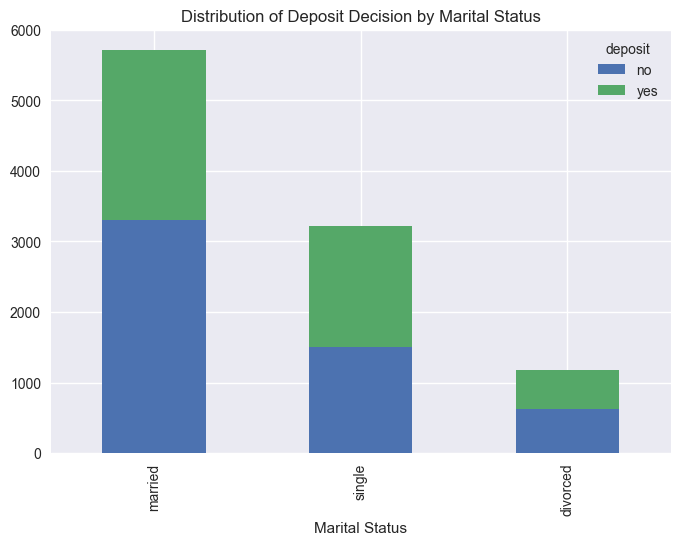

In [66]:
# Plot a visualization for clients who opened and did not open a deposit based on marital status

marital_data = cleaned_df.groupby('marital')['deposit'].value_counts(normalize=False).unstack()
marital_data = marital_data.loc[marital_data.sum(axis=1).sort_values(ascending=False).index]
marital_data.plot(kind='bar', stacked='True')

plt.xlabel('Marital Status')
plt.title('Distribution of Deposit Decision by Marital Status')
plt.show();


**Unmarried clients are more likely to open a deposit than married clients**

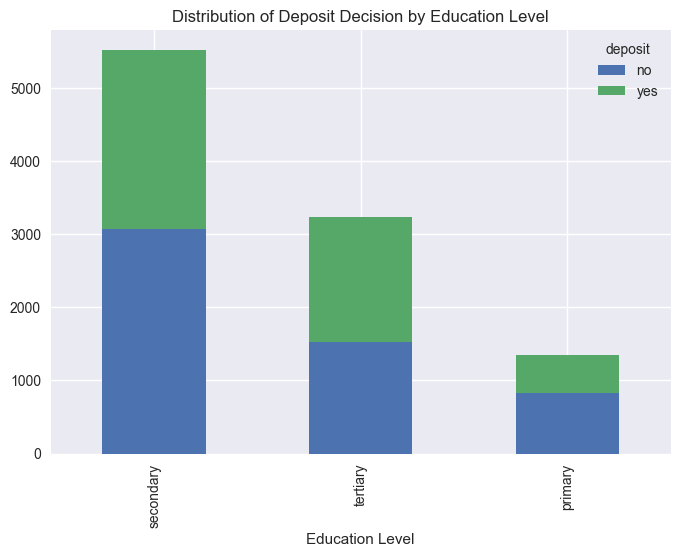

In [67]:
# Plot a visualization for clients who opened and did not open a deposit based on education level

edu_data = cleaned_df.groupby('education')['deposit'].value_counts(normalize=False).unstack()
edu_data = edu_data.loc[edu_data.sum(axis=1).sort_values(ascending=False).index]
edu_data.plot(kind='bar', stacked='True')

plt.xlabel('Education Level')
plt.title('Distribution of Deposit Decision by Education Level')
plt.show();

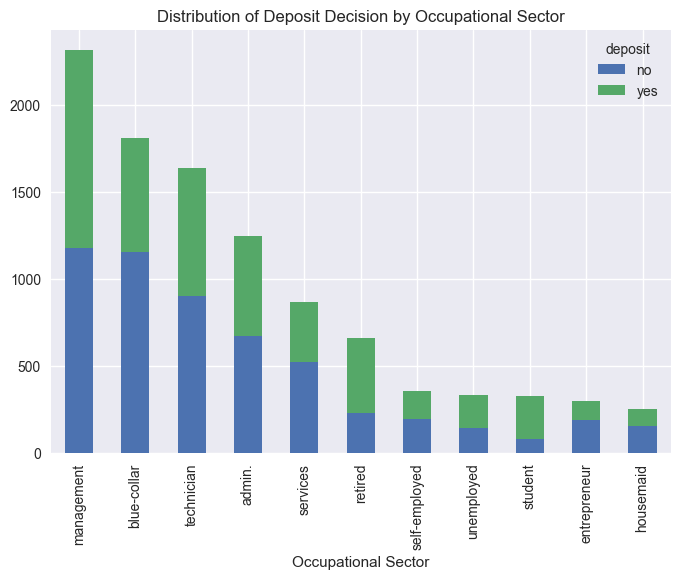

In [68]:
# Plot visualizations for clients who opened and did not open a deposit based on occupational sector

job_data = cleaned_df.groupby('job')['deposit'].value_counts(normalize=False).unstack()
job_data = job_data.loc[job_data.sum(axis=1).sort_values(ascending=False).index]
job_data.plot(kind='bar', stacked='True')

plt.xlabel('Occupational Sector')
plt.title('Distribution of Deposit Decision by Occupational Sector')
plt.show();

**In the occupational sector, retirees and students are more likely to open a deposit, which correlates with age groups**

In [69]:
# Create a pivot table to determine which education and marital status combinations are most likely to result in opening or not opening a deposit
# First, filter the DataFrames

no_data = cleaned_df[cleaned_df['deposit'] == 'no']
yes_data = cleaned_df[cleaned_df['deposit'] == 'yes']

# Pivot table for clients who opened a deposit
pivot_yes = yes_data.pivot_table(index='education', columns='marital', aggfunc='size', fill_value=0)

# Pivot table for clients who did not open a deposit
pivot_no = no_data.pivot_table(index='education', columns='marital', aggfunc='size', fill_value=0)

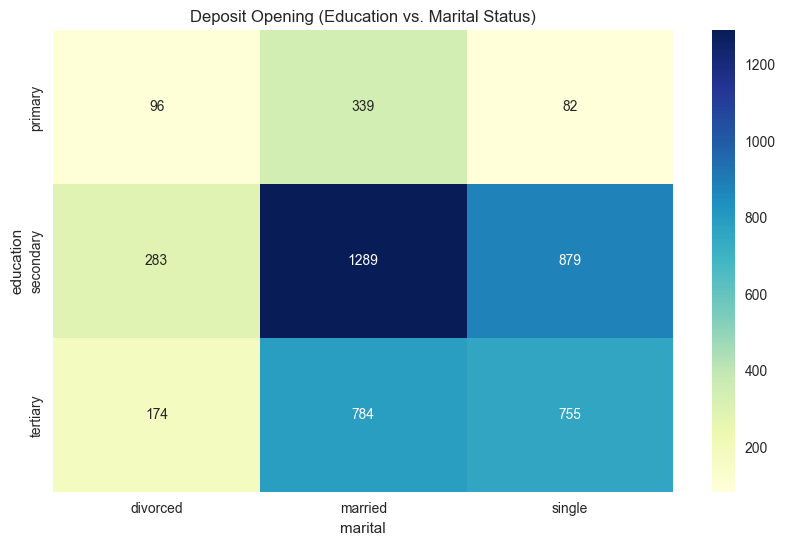

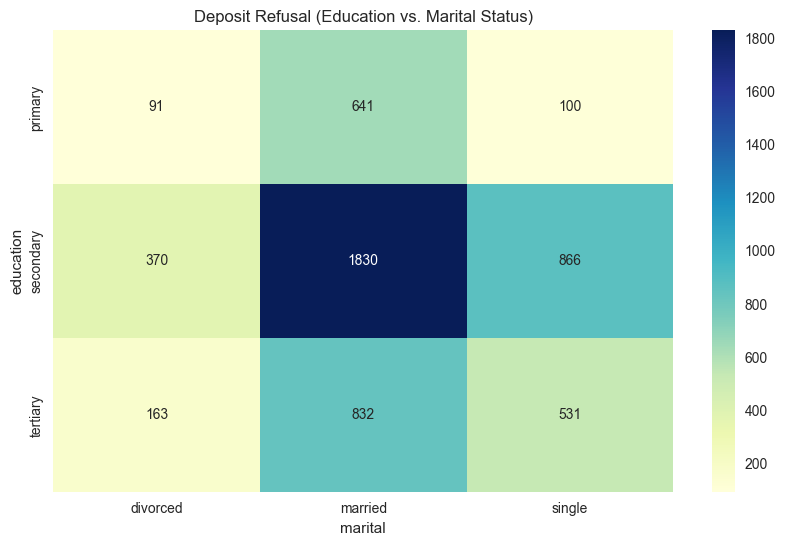

In [70]:
# Plot a heatmap for clients who opened a deposit

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_yes, annot=True, cmap='YlGnBu', fmt='d', cbar=True)
plt.title('Deposit Opening (Education vs. Marital Status)')
#experiment.log_figure('open_deposit_by_marital_status_vs_education', plt)
plt.show();

# Plot a heatmap for clients who did not open a deposit
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_no, annot=True, cmap='YlGnBu', fmt='d', cbar=True)
plt.title('Deposit Refusal (Education vs. Marital Status)')
#experiment.log_figure('not_open_deposit_by_marital_status_vs_education', plt)
plt.show();

- In both cases, the largest group consists of married clients with a secondary education.

- From the heatmap of clients who opened a deposit, unmarried clients with higher education are more likely to open a deposit.

- Conversely, married clients with primary education are more likely to refuse a deposit.

## 3: Data Transformation

Features will be encoded and transformed to prepare the data for the classification task. Building on the data structure understanding gained during preprocessing, this stage will focus on tailoring the data for modeling.

Categorical variables will be encoded into numerical values to enable their use in modeling. `LabelEncoder` will be used to encode categorical variables.

In [71]:
# Transform the education and age_category features

LE = LabelEncoder()
 
cleaned_df['education'] = LE.fit_transform(cleaned_df['education'])
cleaned_df['age_category'] = LE.fit_transform(cleaned_df['age_category'])

In [72]:
# Transform binary variables into 0 and 1 representations for features with 'yes' and 'no' values

cleaned_df['deposit'] = cleaned_df['deposit'].apply(lambda x: 1 if x=='yes' else 0)
cleaned_df['default'] = cleaned_df['default'].apply(lambda x: 1 if x=='yes' else 0)
cleaned_df['housing'] = cleaned_df['housing'].apply(lambda x: 1 if x=='yes' else 0)
cleaned_df['loan'] = cleaned_df['loan'].apply(lambda x: 1 if x=='yes' else 0)

Categorical variables will be encoded using one-hot encoding with `pd.get_dummies()`

In [73]:
# Create dummy variables and merge them with the main DataFrame

dummies_df = pd.get_dummies(cleaned_df[['job', 'marital', 'contact', 'month', 'poutcome']], dtype='int')
data = pd.concat([cleaned_df, dummies_df], axis=1)
data = data.drop(['job', 'marital', 'contact', 'month', 'poutcome'], axis=1)

In [74]:
# Check the shape of the DataFrame after merging

print(f'Shape of the DataFrame after one-hot encoding: {data.shape}')

Shape of the DataFrame after one-hot encoding: (10105, 46)


Text(0.5, 1.0, 'Correlation Matrix')

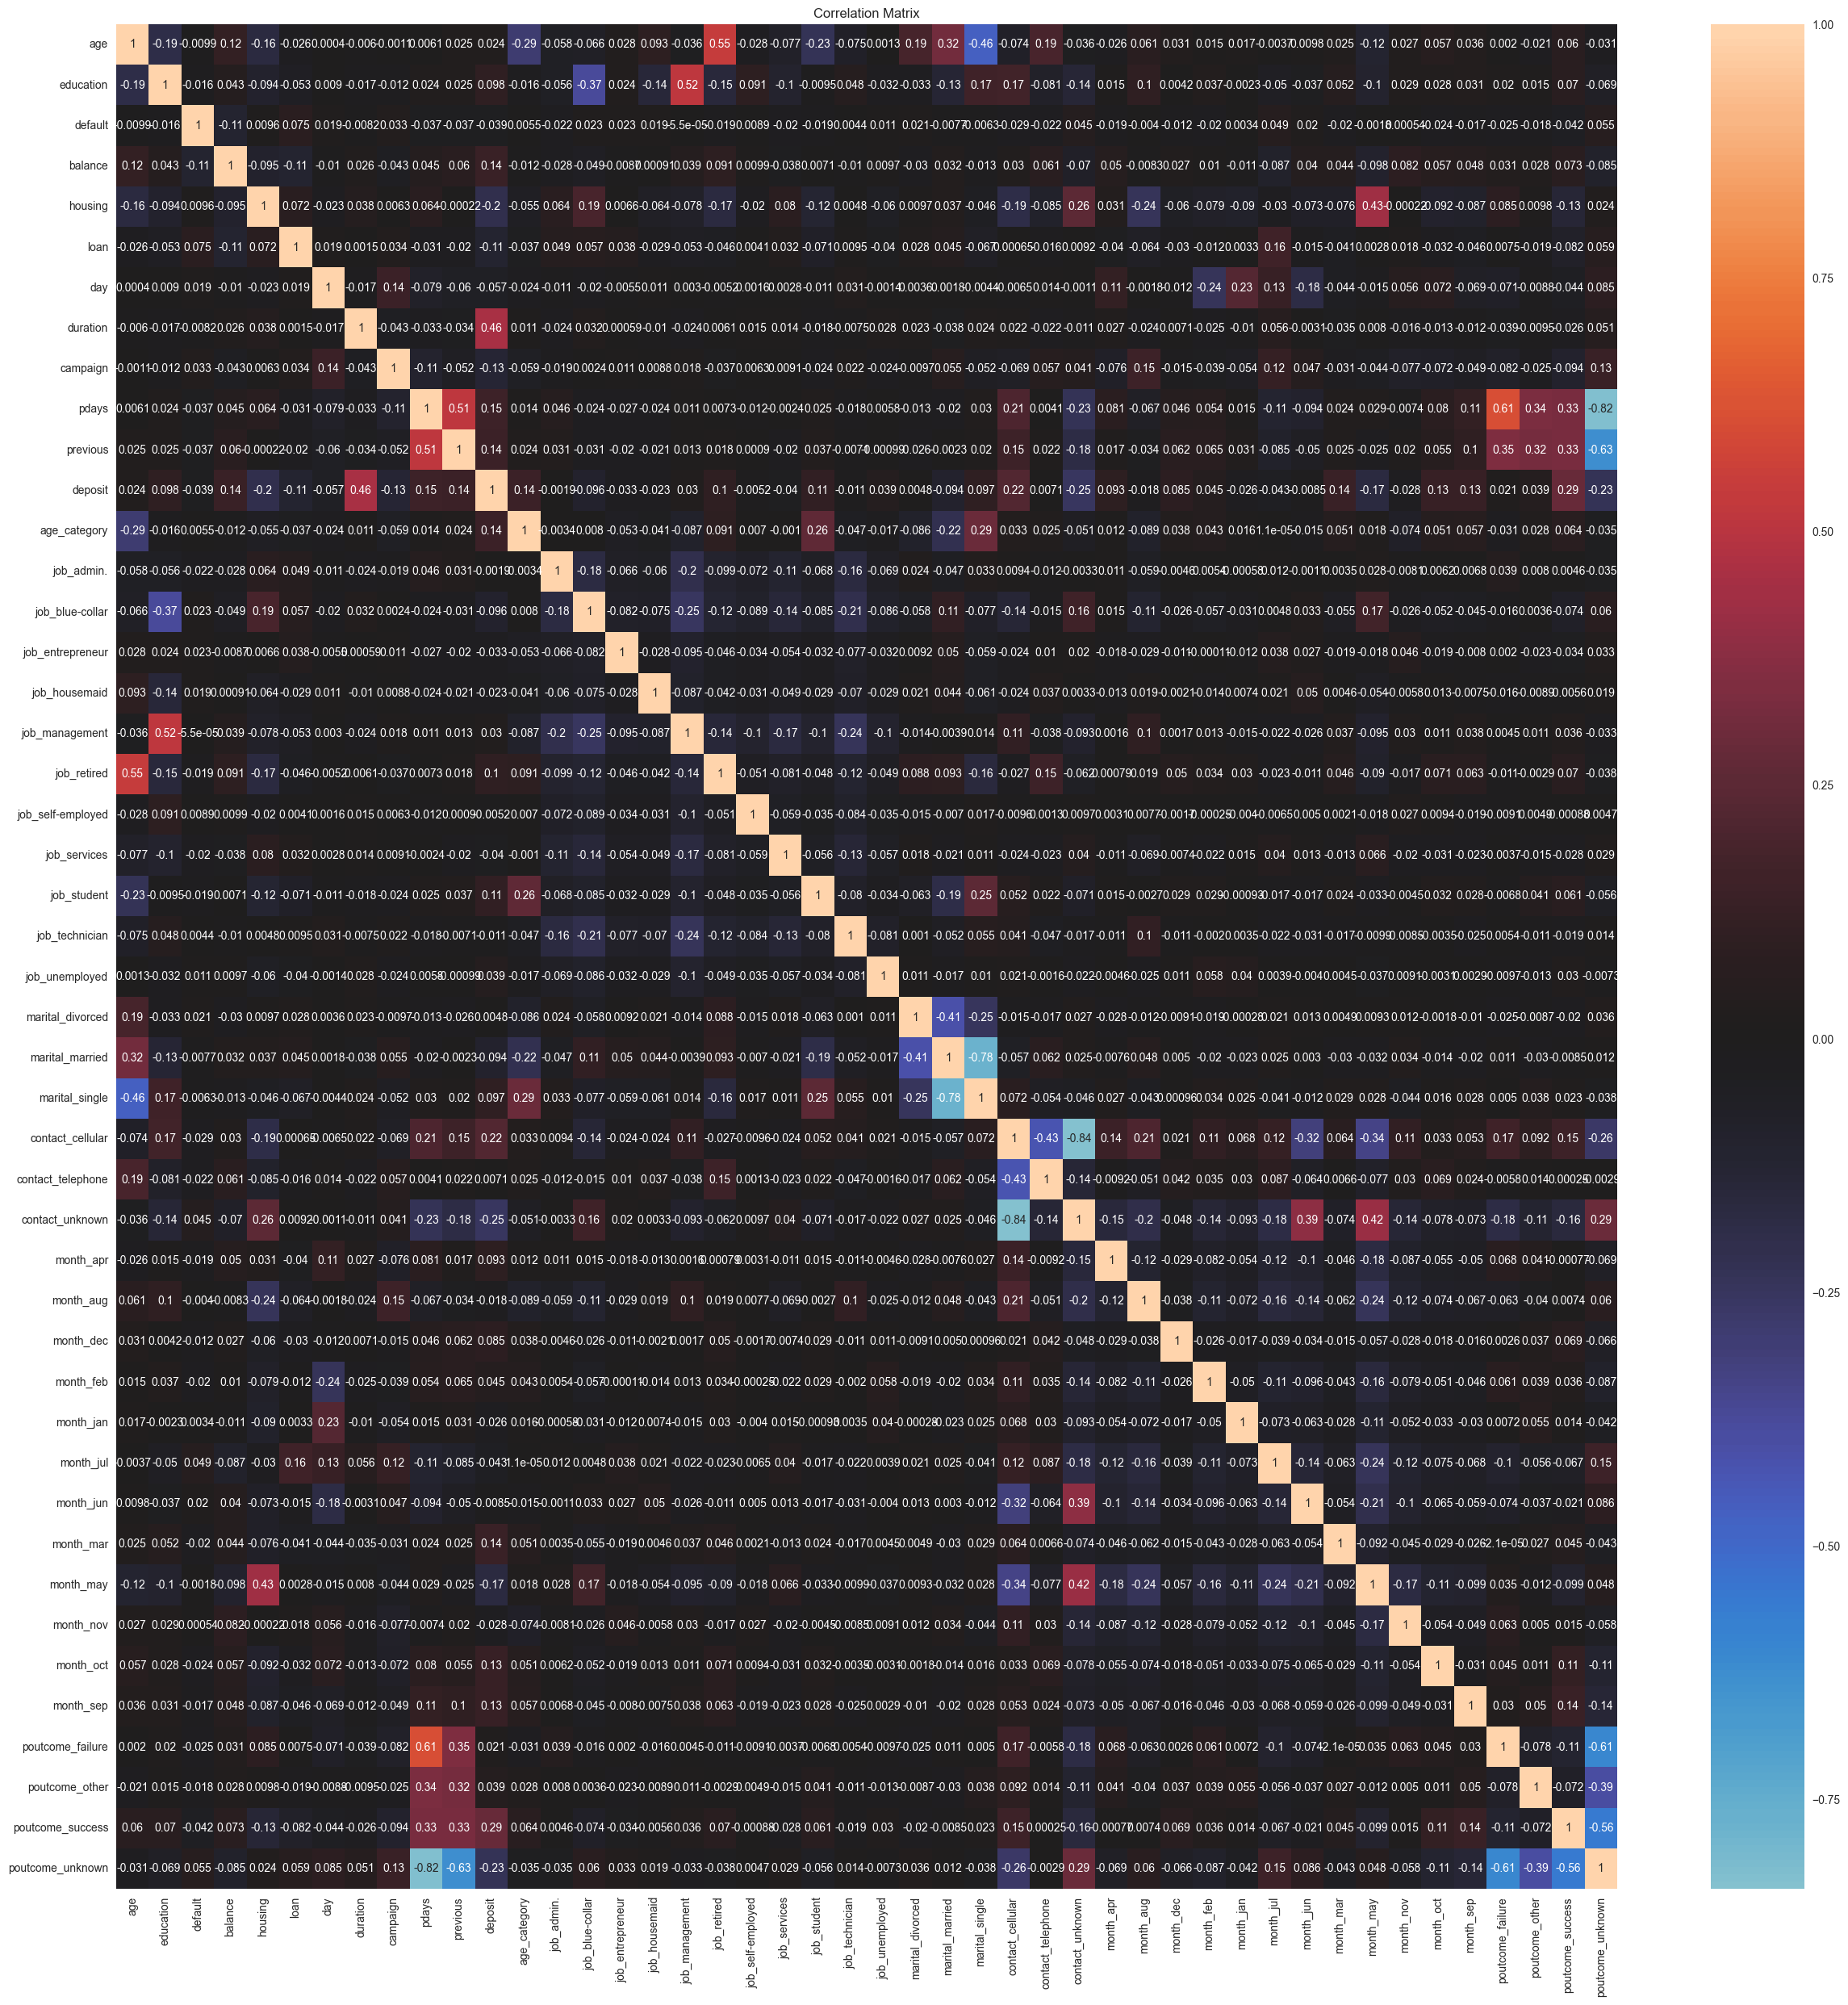

In [75]:
# Build a correlation matrix and assess the data for multicollinearity

plt.figure(figsize=(30,30))
sns.heatmap(data.corr(numeric_only=True), annot=True, center=0);
plt.title('Correlation Matrix')
#experiment.log_figure('correlations', plt)

**No features with multicollinearity are present in the data**

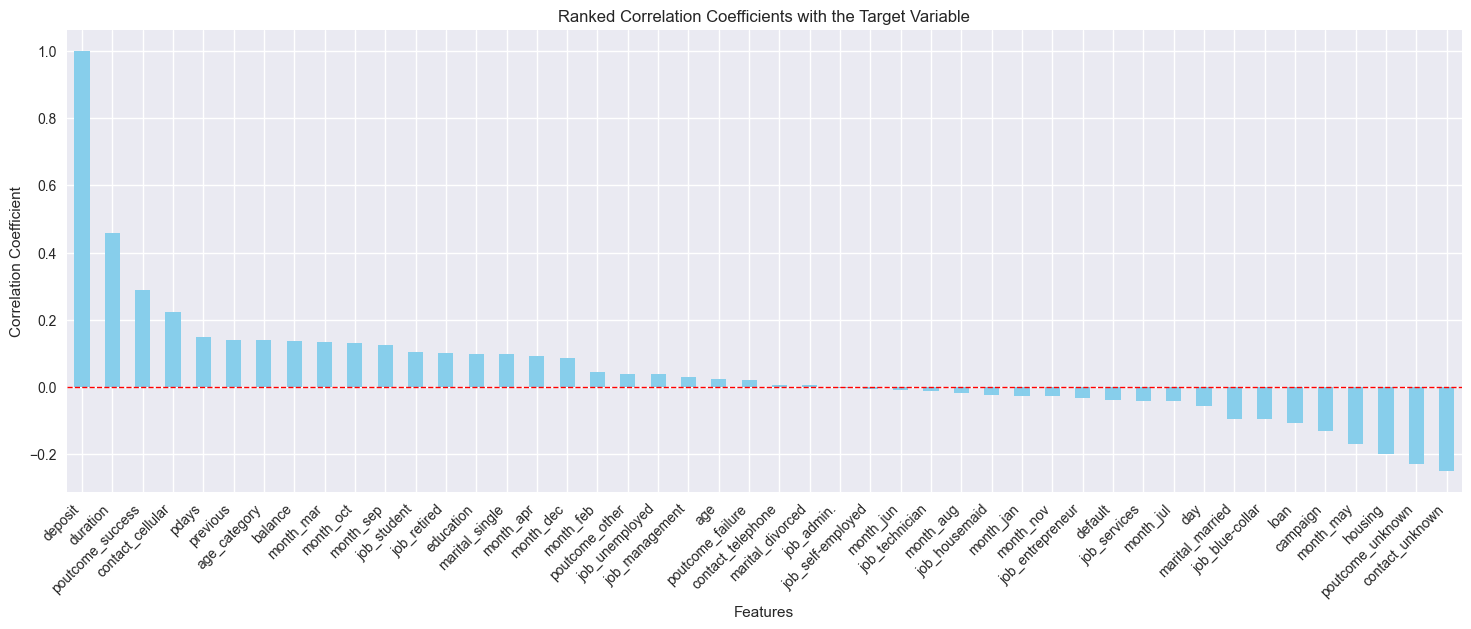

In [76]:
# Plot a bar chart of ranked correlation coefficients for the target feature deposit

correlations = data.corr()['deposit']
sorted_correlations = correlations.sort_values(ascending=False)

plt.figure(figsize=(18, 6))
sorted_correlations.plot(kind='bar', color='skyblue')
plt.title("Ranked Correlation Coefficients with the Target Variable")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='red', linestyle='--', linewidth=1)

#experiment.log_figure('target_features_correlations', plt)
plt.show();

The highest correlations are observed with the features:

- `Duration`

- `poutcome_success`

- `contact_cellular`

However, the correlation values are not high, so these features will be retained in the DataFrame.

The data will be split into training and test sets using `train_test_split()`, with stratification based on the target variable, a `test_size=33%` of the data, and `random_state=42` for reproducibility.

In [77]:
# Split the dataset and target feature, forming training and test sets

X = data.drop(['deposit'], axis=1)
y = data['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.33, random_state=42)

print(f'Shape of the training set: {X_train.shape}')
print(f'Shape of the test set: {X_test.shape}')

Shape of the training set: (6770, 45)
Shape of the test set: (3335, 45)


The top 15 most important features will be selected using `SelectKBest` with the `f_classif` scoring function.

In [78]:
# Use SelectKBest to select the 15 most suitable features and store them in a separate list

selector = SelectKBest(f_classif, k=15)
selector.fit(X_train, y_train)

# Get the selected features and their names

best_features = selector.get_feature_names_out().tolist()
best_features

['balance',
 'housing',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'age_category',
 'contact_cellular',
 'contact_unknown',
 'month_mar',
 'month_may',
 'month_oct',
 'month_sep',
 'poutcome_success',
 'poutcome_unknown']

In [79]:
# Re-form the training and test sets using only the 15 most important features

X = data[best_features]
y = data['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.33, random_state=42)

print(f'Shape of the training set: {X_train.shape}')
print(f'Shape of the test set: {X_test.shape}')

Shape of the training set: (6770, 15)
Shape of the test set: (3335, 15)


Since the data is not normalized, normalization is required for models sensitive to this. `MinMaxScaler` will be used to normalize the data.

In [80]:
# Normalize the data using MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

# Transform the training and test sets using the fitted scaler

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4: Solving the Classification Task: Logistic Regression and Decision Trees

A baseline predictive model using logistic regression and decision trees will be constructed. The model’s quality will be assessed, and optimal parameters will be tuned to achieve the best performance for these algorithms.

Classification model training will begin with logistic regression, using the parameters: 

* `max_iter=1000`,
* `random_state=42`,
* `solver='sag'`

In [81]:
# Train a logistic regression model and calculate quality metrics

model = linear_model.LogisticRegression(max_iter=1000, random_state=42, solver='sag')
model.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate and display metrics for the training and test sets

print('Report for the training set:', '\n', metrics.classification_report(y_train, y_train_pred))
print()
print('Report for the test set:', '\n', metrics.classification_report(y_test, y_test_pred))

accuracy_log_reg = metrics.accuracy_score(y_test, y_test_pred)
f1_score_log_reg = metrics.f1_score(y_test, y_test_pred)

#experiment.log_metric('Accuracy_log_reg_model', accuracy_log_reg)
#experiment.log_metric('F1-Score_log_reg_model', f1_score_log_reg)


Report for the training set: 
               precision    recall  f1-score   support

           0       0.81      0.87      0.84      3634
           1       0.84      0.77      0.80      3136

    accuracy                           0.82      6770
   macro avg       0.83      0.82      0.82      6770
weighted avg       0.83      0.82      0.82      6770


Report for the test set: 
               precision    recall  f1-score   support

           0       0.80      0.86      0.83      1790
           1       0.82      0.74      0.78      1545

    accuracy                           0.81      3335
   macro avg       0.81      0.80      0.81      3335
weighted avg       0.81      0.81      0.81      3335



A decision tree model will be trained, and its quality will be evaluated, using the parameters: 

* `criterion='entropy'`,
* `max_depth=6`,
* `min_samples_split=10`,
* `random_state=42`

In [82]:
# Train a decision tree model and calculate quality metrics

model = tree.DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate and display metrics for the training and test sets

print('Report for the training set:', '\n', metrics.classification_report(y_train, y_train_pred))
print()
print('Report for the test set:', '\n', metrics.classification_report(y_test, y_test_pred))

accuracy_decision_tree = metrics.accuracy_score(y_test, y_test_pred)
f1_score_decision_tree = metrics.f1_score(y_test, y_test_pred)

#experiment.log_metric('Accuracy_log_reg_model', accuracy_decision_tree)
#experiment.log_metric('F1-Score_log_reg_model', f1_score_decision_tree)

Report for the training set: 
               precision    recall  f1-score   support

           0       0.86      0.79      0.82      3634
           1       0.78      0.85      0.81      3136

    accuracy                           0.82      6770
   macro avg       0.82      0.82      0.82      6770
weighted avg       0.82      0.82      0.82      6770


Report for the test set: 
               precision    recall  f1-score   support

           0       0.85      0.78      0.81      1790
           1       0.77      0.84      0.80      1545

    accuracy                           0.81      3335
   macro avg       0.81      0.81      0.81      3335
weighted avg       0.81      0.81      0.81      3335



Tune hyperparameters for the decision tree model using GridSearchCV, find the best parameters in min_samples-split and max_depth

In [83]:
# Tune optimal parameters using GridSearchCV and fit the model

param_grid = {
    'min_samples_split': [2, 5, 7, 10],
    'max_depth':[3,5,7]
}

grid_search = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(
        random_state=42,
        criterion='entropy'
    ),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

# Make predictions on the test sets

y_test_pred = grid_search.predict(X_test_scaled)

# Calculate and display metrics for the training and test sets, including the best hyperparameter values

print('Report for the test set:', '\n', metrics.classification_report(y_test, y_test_pred))
print('f1_score on the test set: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Best hyperparameter values: {}".format(grid_search.best_params_))

accuracy_grid_search = metrics.accuracy_score(y_test, y_test_pred)
f1_score_grid_search = metrics.f1_score(y_test, y_test_pred)

#experiment.log_metric('Accuracy_grid_search', accuracy_grid_search)
#experiment.log_metric('F1-Score_grid_search', f1_score_grid_search)

Report for the test set: 
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      1790
           1       0.79      0.82      0.81      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.82      0.82      0.82      3335

f1_score on the test set: 0.81
Best hyperparameter values: {'max_depth': 7, 'min_samples_split': 10}


## 5: Solving the Classification Task: Ensemble Models and Prediction Building

Predictions will be refined using advanced ensemble methods (e.g., random forest, gradient boosting, and stacking). The performance of various models will be compared to determine the one delivering the highest-quality predictions

An ensemble model based on decision trees will be trained, using the parameters:

* `n_estimators=100`,
* `criterion='gini'`,
* `min_samples_leaf=5`,
* `max_depth=10`,
* `random_state=42`

In [84]:
# Train a random forest model on the data

model = ensemble.RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate and display metrics for the training and test sets

print('Report for the training set:', '\n', metrics.classification_report(y_train, y_train_pred))
print()
print('Report for the test set:', '\n', metrics.classification_report(y_test, y_test_pred))

accuracy_random_forest = metrics.accuracy_score(y_test, y_test_pred)
f1_score_random_forest = metrics.f1_score(y_test, y_test_pred)

#experiment.log_metric('Accuracy_random_forest', accuracy_random_forest)
#xperiment.log_metric('F1-Score_random_forest', f1_score_random_forest)

Report for the training set: 
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      3634
           1       0.84      0.86      0.85      3136

    accuracy                           0.86      6770
   macro avg       0.86      0.86      0.86      6770
weighted avg       0.86      0.86      0.86      6770


Report for the test set: 
               precision    recall  f1-score   support

           0       0.85      0.82      0.83      1790
           1       0.80      0.83      0.81      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.83      0.82      0.82      3335



Gradient boosting will be used for classification, with the parameters:

* `learning_rate=0.05`,
* `n_estimators=500`,
* `min_samples_leaf=5`,
* `max_depth=5`,
* `random_state=42`

In [85]:
# Use gradient boosting for classification and compare its quality with random forest

model = ensemble.GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=500,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate and display metrics for the training and test sets

print('Report for the training set:', '\n', metrics.classification_report(y_train, y_train_pred))
print()
print('Report for the test set:', '\n', metrics.classification_report(y_test, y_test_pred))

accuracy_boosting = metrics.accuracy_score(y_test, y_test_pred)
f1_score_boosting = metrics.f1_score(y_test, y_test_pred)

#experiment.log_metric('Accuracy_gradient_boosting', accuracy_boosting)
#experiment.log_metric('F1-Score_gradient_boosting', f1_score_boosting)

Report for the training set: 
               precision    recall  f1-score   support

           0       0.92      0.91      0.91      3634
           1       0.90      0.90      0.90      3136

    accuracy                           0.91      6770
   macro avg       0.91      0.91      0.91      6770
weighted avg       0.91      0.91      0.91      6770


Report for the test set: 
               precision    recall  f1-score   support

           0       0.85      0.81      0.83      1790
           1       0.79      0.83      0.81      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.82      0.82      0.82      3335



On the training set, GBC performed better, but on the test set, the result is slightly weaker.

The previously trained logistic regression, decision tree, and random forest models will be combined into a stacking ensemble.

In [86]:
# Combine known algorithms using stacking. Pass models with the parameters used previously

estimators = [
    ('dt', tree.DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=7, min_samples_split=10)),
    ('lr', linear_model.LogisticRegression(random_state=42, max_iter=1000, solver='sag')),
    ('gbc', ensemble.GradientBoostingClassifier(learning_rate=0.05, n_estimators=500, min_samples_leaf=5, max_depth=5, random_state=42))
]

# Use a logistic regression model with default parameters as the meta-model

reg = StackingClassifier(
    estimators=estimators,
    final_estimator=linear_model.LogisticRegression(random_state=42)
)

reg.fit(X_train_scaled, y_train)

StackingClassifier(estimators=[('dt',
                                DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=7,
                                                       min_samples_split=10,
                                                       random_state=42)),
                               ('lr',
                                LogisticRegression(max_iter=1000,
                                                   random_state=42,
                                                   solver='sag')),
                               ('gbc',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           max_depth=5,
                                                           min_samples_leaf=5,
                                                           n_estimators=500,
                                                           random_state=42))],
                   final_estimator=LogisticRegression(random_state=42))

In [87]:
# Generate predictions and display results

y_train_pred = reg.predict(X_train_scaled)
y_test_pred = reg.predict(X_test_scaled)

print('Report for the training set:', '\n', metrics.classification_report(y_train, y_train_pred))
print()
print('Report for the test set:', '\n', metrics.classification_report(y_test, y_test_pred))

accuracy_stacking = metrics.accuracy_score(y_test, y_test_pred)
f1_score_stacking = metrics.f1_score(y_test, y_test_pred)

#experiment.log_metric('Accuracy_stacking', accuracy_stacking)
#experiment.log_metric('F1-Score_stacking', f1_score_stacking)

Report for the training set: 
               precision    recall  f1-score   support

           0       0.88      0.89      0.88      3634
           1       0.87      0.86      0.86      3136

    accuracy                           0.88      6770
   macro avg       0.87      0.87      0.87      6770
weighted avg       0.88      0.88      0.88      6770


Report for the test set: 
               precision    recall  f1-score   support

           0       0.83      0.83      0.83      1790
           1       0.81      0.80      0.81      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.82      0.82      0.82      3335




 Top 3 features:
             Feature  Importance
2           duration    0.493586
13  poutcome_success    0.111033
0            balance    0.076521


<Figure size 800x600 with 0 Axes>

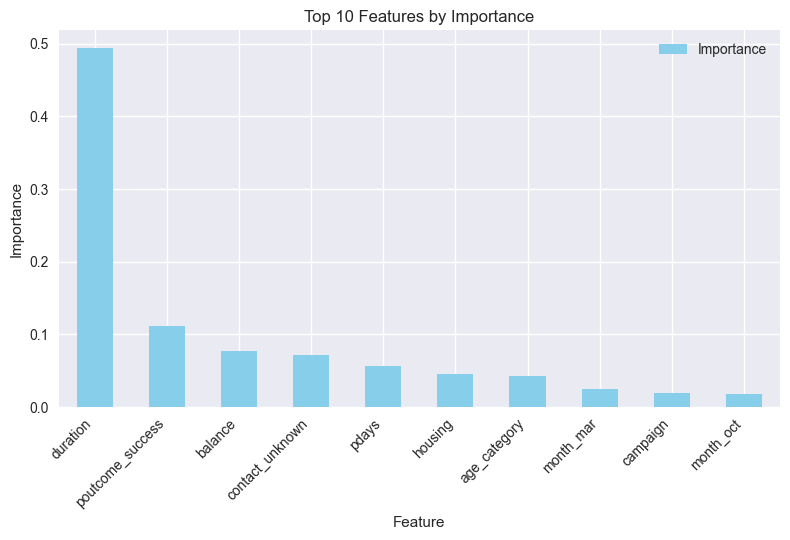

In [88]:
# Check if feature names are available

feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else [f'Feature {i}' for i in range(X_train.shape[1])]

# Obtain feature importance

feature_importances = model.feature_importances_

# Create a DataFrame with feature names and their importance

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Select the three most important features

top_3_features = importance_df.head(3)

print("\n Top 3 features:")
print(top_3_features)

# Visualize feature importance

plt.figure(figsize=(8, 6))
importance_df.set_index('Feature').head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Features by Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#experiment.log_figure('Feature_importance', plt)
plt.show();

Top 3 features after fitting:

* `duration`;
* `poutcome_success`;
* `balance`

Use optuna to optimize hyperparameters for the decision tree model, try to find the best parameters and improve the model

In [89]:
# Implement hyperparameter optimization using Optuna

random_state = 42

def optuna_rf(trial):
    
    # Define the hyperparameter search space
    
    n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
    max_depth = trial.suggest_int('max_depth', 10, 30, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

    # Create the model
    
    model = ensemble.RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state
    )
    
    # Train the model
    
    model.fit(X_train_scaled, y_train)
    score = metrics.f1_score(y_train, model.predict(X_train_scaled))
    
    return score

In [90]:
# Create a study object

study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")

# Search for the best hyperparameter combination n_trials times

study.optimize(optuna_rf, n_trials=20)

[I 2025-05-05 15:39:02,774] A new study created in memory with name: RandomForestClassifier
[I 2025-05-05 15:39:03,445] Trial 0 finished with value: 0.847887323943662 and parameters: {'n_estimators': 184, 'max_depth': 20, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.847887323943662.
[I 2025-05-05 15:39:03,914] Trial 1 finished with value: 0.8752543434027235 and parameters: {'n_estimators': 115, 'max_depth': 24, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.8752543434027235.
[I 2025-05-05 15:39:04,546] Trial 2 finished with value: 0.8529273269502433 and parameters: {'n_estimators': 187, 'max_depth': 11, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.8752543434027235.
[I 2025-05-05 15:39:05,047] Trial 3 finished with value: 0.8898623279098874 and parameters: {'n_estimators': 110, 'max_depth': 27, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.8898623279098874.
[I 2025-05-05 15:39:05,471] Trial 4 finished with value: 0.8476862745098039 and parameters: {'n_e

In [91]:
# Output results on the training set

print("Best hyperparameter values: {}".format(study.best_params))
print("f1_score on the training set: {:.2f}".format(study.best_value))


Best hyperparameter values: {'n_estimators': 154, 'max_depth': 30, 'min_samples_leaf': 2}
f1_score on the training set: 0.92


In [92]:
# Calculate accuracy for the test set

model = ensemble.RandomForestClassifier(**study.best_params,random_state=random_state)
model.fit(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print('Report for the training set:', '\n', metrics.classification_report(y_train, y_train_pred))
print()
print('Report for the test set:', '\n', metrics.classification_report(y_test, y_test_pred))

accuracy_optuna = metrics.accuracy_score(y_test, y_test_pred)
f1_score_optuna = metrics.f1_score(y_test, y_test_pred)

#experiment.log_metric('Accuracy_random_forest_with_optuna', accuracy_optuna)
#experiment.log_metric('F1-Score_random_forest_with_optuna', f1_score_optuna)
#experiment.log_confusion_matrix(np.array(y_test), y_test_pred)

Report for the training set: 
               precision    recall  f1-score   support

           0       0.95      0.92      0.93      3634
           1       0.91      0.94      0.92      3136

    accuracy                           0.93      6770
   macro avg       0.93      0.93      0.93      6770
weighted avg       0.93      0.93      0.93      6770


Report for the test set: 
               precision    recall  f1-score   support

           0       0.85      0.81      0.83      1790
           1       0.79      0.84      0.81      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.83      0.82      0.82      3335



**The F1 Score metric on the test set was improved, achieving a precision score of 0.82. Additionally, the recall on the test set reached 0.84, which is the best result.**

In [93]:
# End the experiment

#experiment.end()